<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week2_Tutorial_Energy_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tutorial of Week 2**

Step 1: Load and Inspect the Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/energy_cleaned.csv")
#head is used to find the first value of data
df.head()


,Country,%Renewable,Region
0,Nepal,89,Asia
1,India,45,Asia
2,Kenya,50,Africa
3,Brazil,95,South America
4,Australia,35,Oceania


Try:

In [ ]:
#summary of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     6 non-null      object
 1   %Renewable  6 non-null      int64 
 2   Region      6 non-null      object
dtypes: int64(1), object(2)
memory usage: 276.0+ bytes


In [ ]:
#Show the statistical information of data
df.describe()

,%Renewable
count,6.000000
mean,60.333333
std,25.136958
min,35.000000
25%,45.750000
50%,49.000000
75%,79.250000
max,95.000000


Question: Are there any unusual values or column names?

Answer:No there is no unusual values but has column name with percent sign in renewable column that can effect with mismatch text with symbol while doing operations.

Step 2: Filter Data Based on Probability

In [ ]:
high_renew = df[df["%Renewable"] > 50]
print("Countries with >50% renewable energy:", len(high_renew))

print(high_renew)

Countries with >50% renewable energy: 2
  Country  %Renewable         Region
0   Nepal          89           Asia
3  Brazil          95  South America


Try This: Change the threshold to 60 or 70. How many countries meet the new criteria?

In [ ]:
high_renew1 = df[df["%Renewable"] > 60]
print("Countries with >60% renewable energy:", len(high_renew1))

Countries with >60% renewable energy: 2


In [ ]:
high_renew2 = df[df["%Renewable"] > 70]
print("Countries with >70% renewable energy:", len(high_renew2))

Countries with >70% renewable energy: 2


In [ ]:
high_renew3 = df[df["%Renewable"] < 50]
print("Countries with <50% renewable energy:", len(high_renew3))

Countries with <50% renewable energy: 3


Question: What proportion of countries use mostly renewable energy?

Answeer: using probability formula: 2/6=1/3=0.33 in percentage: 33% use mostly renewable energy.

Step 3: Compare Averages by Region

In [ ]:
region_avg = df.groupby("Region")["%Renewable"].mean()
print(region_avg)


Region
Africa           50.0
Asia             67.0
Europe           48.0
Oceania          35.0
South America    95.0
Name: %Renewable, dtype: float64


<Axes: xlabel='Region'>

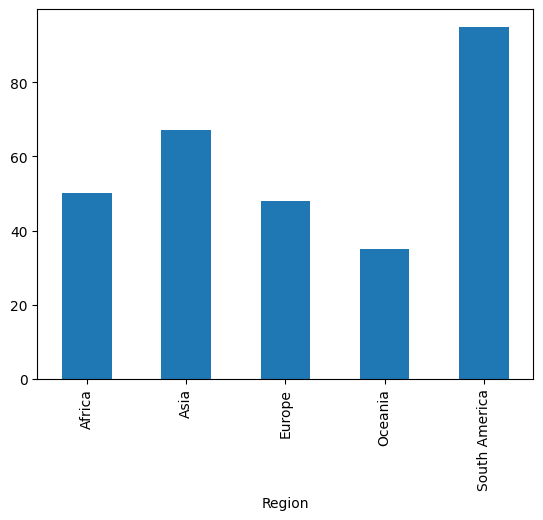

In [ ]:
region_avg.plot(kind='bar')

Question: Which region has the highest average renewable use?

Answer: South America which is 95%

Step 4: Create a Histogram

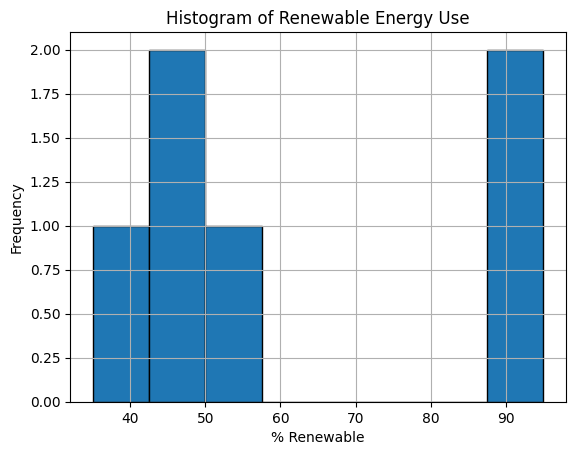

In [ ]:
import matplotlib.pyplot as plt

df["%Renewable"].plot(kind="hist", bins=8, edgecolor="black")
plt.title("Histogram of Renewable Energy Use")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

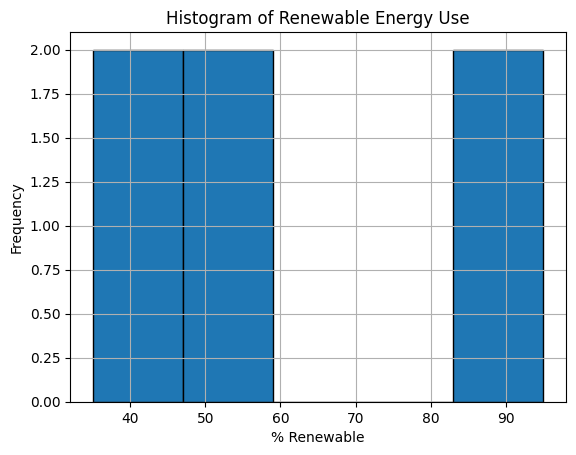

In [ ]:
#Reduce the number of bins to 5 and observe the change. #bins are interval between the values
import matplotlib.pyplot as plt

df["%Renewable"].plot(kind="hist", bins=5, edgecolor="black")
plt.title("Histogram of Renewable Energy Use")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

Question: Are most countries clustered around certain values?

Answer:Yes, there is clustering one one lower end around 35% to 60% due to 4 out of 6 countries being on that scale. next is on around 90% with 2 countries.

Step 5: Create a Density Plot (KDE)

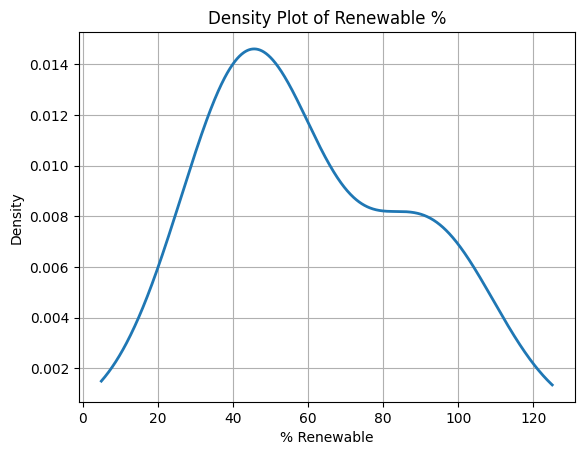

In [ ]:
df["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of Renewable %")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

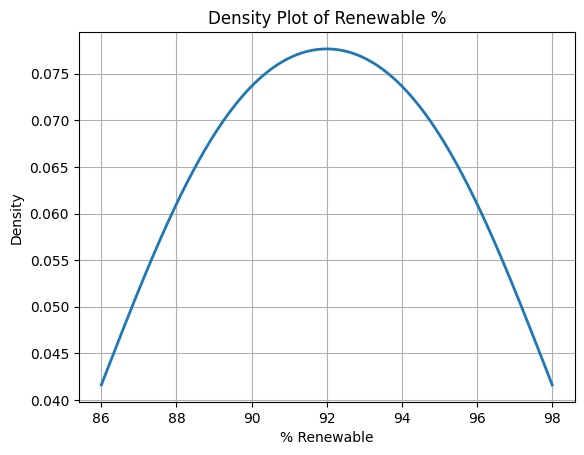

In [ ]:
#Filter only countries using >50% renewables and replot the KDE.
high_renew = df[df["%Renewable"] > 50]
high_renew["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of Renewable %")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

Question: Does the distribution appear normal, skewed, or multimodal?

Answer: without filter multimodal i.e. more than one peak on the centre of graph.

With filter normal i.e only one peak at centre of graph.

Step 6: Compare Distributions by Region

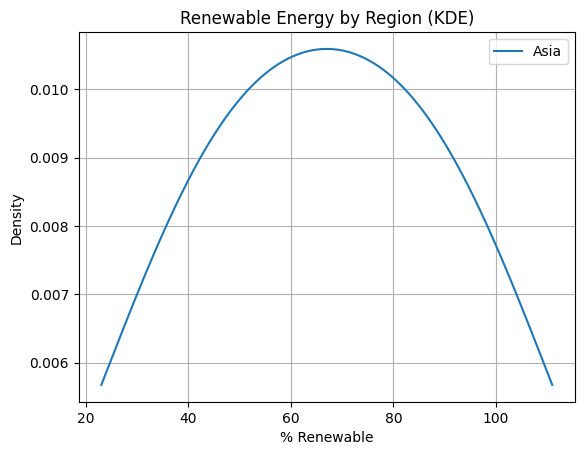

In [ ]:
for region, group in df.groupby("Region"):
    if len(group) >= 2:
        group["%Renewable"].plot(kind="density", label=region)

plt.title("Renewable Energy by Region (KDE)")
plt.xlabel("% Renewable")
plt.legend()
plt.grid(True)
plt.show()

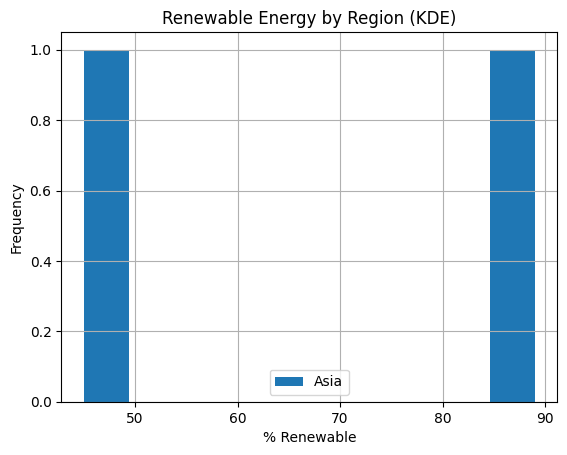

In [ ]:
#Try This: Change kind="density" to kind="hist" for grouped histograms.
for region, group in df.groupby("Region"):
    if len(group) >= 2:
        group["%Renewable"].plot(kind="hist", label=region)

plt.title("Renewable Energy by Region (KDE)")
plt.xlabel("% Renewable")
plt.legend()
plt.grid(True)
plt.show()

**Question: Which region has the highest consistency in renewable use? **

Answer: with Asia being only region with multiple countries in filtered dataset, it has variation

but other region with one country is more consistent.

# **Summary Questions**

**What does the histogram tell us about global energy use?**

Answer: Histogram tells us that global energy use is divided into two distinct side. one is less with 50% use and one is with high around 90% use leaving a significant gap with values around the 60-70% energy use.

**Which regions are leading in renewable energy adoption?**

Answer: Highest one is South America with 95% renewable energy adoption and next is Asia with 67% but other regions are below or around 50% renewable energy adoption.

**What surprising trends did you notice during exploration?**

Answer: One is the polarization of renewable energy use where most of the countries are missing the middle 60% mark that lacks the proper use plans of using them with proper utilization.

Next is developed countries like Australia And Germany are lacking behind to utilize the resources while developing counries like Nepal and Brazil are high on using the renewable energy with their resources.

**How might this analysis help shape global energy policies?**

Answer: This has given the best insights of countries of their usage in renewable energy i.e the countries with less renewable usage are more advanced with technology. so they must focus on using thier resources with planning can easily help them get the better results. In other hand, countries with high renewable use has better natural resources for renewable energy. so, their plans should be more emphasis on utilizing those resources properly to get even more results or maintain with improvement policies.